## Evaluating classifiers


  **A nice article for reference**: https://towardsdatascience.com/beyond-accuracy-precision-and-recall-3da06bea9f6c

* **Learning objective**: 
    * Understand the main tools available to judge your model
    * **sklearn.metrics** is your friend!
* **Content to be covered**:
    * True & False /  Positives & Negatives: 
    * Accuracy
    * Precision vs recall
    * ROC and AUC
    * Confusion matrix


### True & False /  Positives & Negatives:

| Scenario | Predicted: NO | Predicted: YES |
| --- | ----- | --- |
| **Actual: NO** | TN | FP |
| **Actual: YES** | FN | TP |

#### Scenario 1: Gold Diggers!
* We build a scanner which scans earth samples from different regions for gold. If we find it we excavate that area.
* Important to consider: Excavating earth is expensive! So if we don't find gold we lose lots of money! 
* Input: 100 potential sites (data points) for gold. The model says: 70 positives, 30 negatives. Actually, 90 positives, 10 negatives.
* How good is our model?


#### Scenario 2: Test for Breast Cancer
* We build a tool which tests mammograms for the presence of breast cancer.
* Input: 100 mammograms. The model says: 70 cancerous, 30 clear. Actually, 90 cancerous, 10 clear.
* How good is our model?




---

## I. GET AND EXPLORE THE DATA

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [2]:
X_full, y_full = load_breast_cancer(return_X_y=True, as_frame=True)


In [4]:
y_full

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full)

#### Simple Model

In your own version remember to do train-test split.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [20]:
m = LogisticRegression(max_iter=10000) # create a model
#m2 = RandomForestClassifier()

Normally here you make the train-test split.

In [21]:
m.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [22]:
m.score(X_train, y_train) #calculating the score == accuracy score

0.9624413145539906

In [23]:
m.score(X_test,y_test)

0.958041958041958

## II. EVALUATION METRICS

### Accuracy:
* The percentage of correct guesses
* A nice simple way of assessing the model
* Fails with class imbalance


$$Acc = \frac{TP+TN}{TP+TN+FP+FN}$$

---

In [25]:
from sklearn.metrics import accuracy_score 

ypred = m.predict(X_train) #generating predictive results
accuracy_score(y_train, ypred) #compare predictive results to actual results


0.9624413145539906

In [ ]:
#m.score(X, y)

Check the difference of the syntax in the below methods:
    
- m.score()
- accuracy_score()

### Precision vs recall
* A trade off between exactness and totalness
* Precision => **Exactness** 
    * High Precision = more relevant than irrelevant results returned (at the expense of missing some relevant ones)
    * It is high if the FP is low.
   
$$P = \frac{TP}{TP+FP}$$

* Recall => **Inclusiveness** 
    * High Recall = most of the relevant results returned - at the expense of including bad results.
    * Also called True Positive Rate.
    * It is high if the FN is low.


    
$$R = \frac{TP}{TP+FN}$$

* Remember the two scenarios! Which one suits which measure?




### F1 score 

It is the harmonic mean of the precision and recall.



$$ F1 = 2* \frac{precision * recall} {precision + recall}$$

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [28]:
print(f"""precision = {round(precision_score(y_train,ypred),2)} \n 
recall = {round(recall_score(y_train,ypred),2)}\n
f1 = {round(f1_score(y_train,ypred),2)}""")

precision = 0.96 
 
recall = 0.98

f1 = 0.97


## III. Confusion Matrix
* Let's plot the confusion matrix of scenario two, and then prettify it with seaborn
* Refer above to understand the structure

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

conf = confusion_matrix(y_train, ypred)
conf

array([[150,  10],
       [  6, 260]])

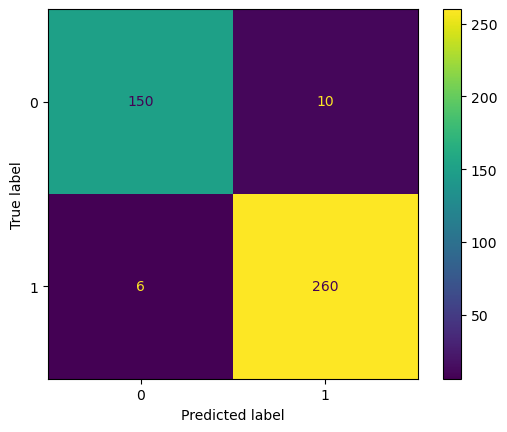

In [31]:
plotting = ConfusionMatrixDisplay(conf)
plotting.plot();

Or with the heatmap method.

In [38]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
#%matplotlib inline

def plot_heatmap(confusion):
    
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion,
                xticklabels = np.unique(y),
                yticklabels = np.unique(y),
                cmap = 'BuPu',
                annot=True,
                fmt = 'g'
               )

    # fmt is used to switch off scientific notation
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('Actual', fontsize = 14)

    #https://fmt.dev/latest/syntax.html

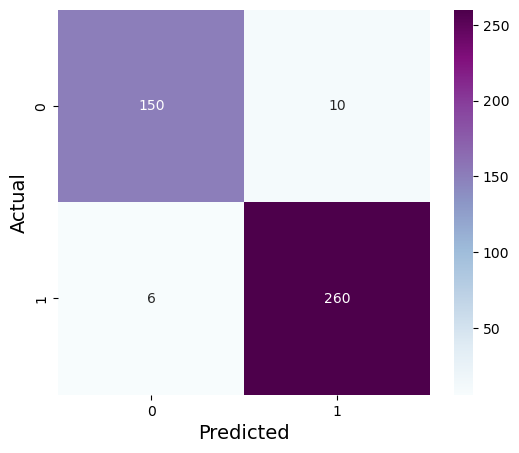

In [39]:
plot_heatmap(conf)


- TPR: TP/Actual Positives (Sensitivity, Recall)
- TNR: TN/Actual Negatives (Specifity)
- FPR: FP/Actual Negatives
- FNR: FN/Actual Positives

## IV. Receiver Operator Curve (ROC) and Area Under the Curve (AUC).


* ROC plots TPR (y axis) against FPR (x axis) for every classification threshold. The typical threshold for logistic regression is 0.5.

$$fpr = \frac{fp}{N} $$

$$tpr = \frac{tp}{P} $$

In [45]:
from sklearn.metrics import plot_roc_curve, roc_curve, auc

Getting the probabilities for the two classes

In [58]:
y_pred = m.predict(X_train)


1

In [57]:
X_train.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
558,14.59,22.68,96.39,657.1,0.08473,0.133,0.1029,0.03736,0.1454,0.06147,...,15.48,27.27,105.9,733.5,0.1026,0.3171,0.3662,0.1105,0.2258,0.08004


In [71]:
m.predict_proba(X_train)

array([[4.60529261e-02, 9.53947074e-01],
       [3.48083286e-01, 6.51916714e-01],
       [6.65877513e-06, 9.99993341e-01],
       [7.11468395e-02, 9.28853160e-01],
       [5.79406729e-03, 9.94205933e-01],
       [2.77036182e-02, 9.72296382e-01],
       [3.57341353e-02, 9.64265865e-01],
       [9.49040212e-01, 5.09597876e-02],
       [3.19205134e-01, 6.80794866e-01],
       [4.24074378e-01, 5.75925622e-01],
       [2.85208471e-03, 9.97147915e-01],
       [2.11052128e-04, 9.99788948e-01],
       [9.98928058e-01, 1.07194198e-03],
       [2.79736910e-04, 9.99720263e-01],
       [1.15849488e-03, 9.98841505e-01],
       [9.99977104e-01, 2.28958541e-05],
       [8.32537158e-01, 1.67462842e-01],
       [3.06042201e-04, 9.99693958e-01],
       [9.99995515e-01, 4.48460007e-06],
       [1.00000000e+00, 9.31736597e-17],
       [3.17373126e-02, 9.68262687e-01],
       [1.00000000e+00, 5.35549449e-16],
       [1.00000000e+00, 1.62714192e-13],
       [1.27521106e-01, 8.72478894e-01],
       [1.050615

Plot the ROC curve

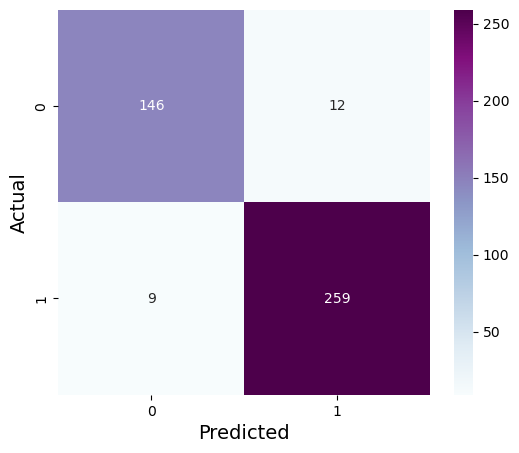

In [59]:
conf = confusion_matrix(y, m.predict(X))
plot_heatmap(conf)

What is the actual best threshold?

In [61]:
#m.predict_proba(X)[:,1]

In [62]:
fpr, tpr, threshold = roc_curve(y_train, m.predict_proba(X_train)[:,1]);

/usr/local/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
  warnings.warn(msg, category=FutureWarning)


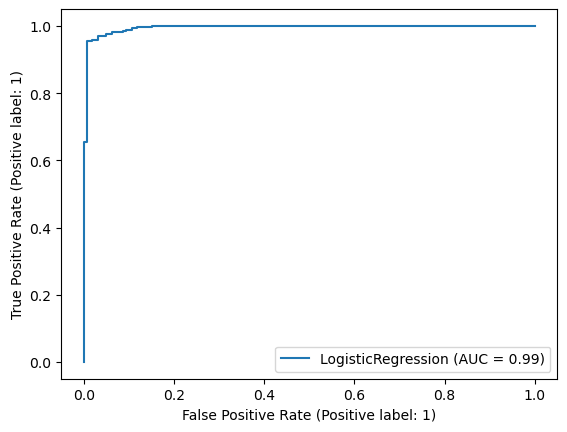

In [63]:
plot_roc_curve(m, X_train, y_train)

In [65]:
print(f"""
      fpr={fpr} \n 
      
      tpr={tpr} \n 
      
      thresholds={np.round(threshold, 2)}""")


      fpr=[0.      0.      0.      0.00625 0.00625 0.01875 0.01875 0.03125 0.03125
 0.05    0.05    0.0625  0.0625  0.0875  0.0875  0.09375 0.09375 0.10625
 0.10625 0.11875 0.11875 0.15    0.15    1.     ] 
 
      
      tpr=[0.         0.0037594  0.65413534 0.65413534 0.95488722 0.95488722
 0.95864662 0.95864662 0.96992481 0.96992481 0.97744361 0.97744361
 0.98120301 0.98120301 0.98496241 0.98496241 0.9887218  0.9887218
 0.9924812  0.9924812  0.9962406  0.9962406  1.         1.        ] 
 
      
      thresholds=[2.   1.   0.99 0.99 0.81 0.8  0.76 0.73 0.65 0.6  0.55 0.52 0.5  0.42
 0.37 0.36 0.34 0.26 0.26 0.2  0.19 0.13 0.09 0.  ]


Best threshold (find the index you need from threshold array)

In [67]:
tpr-fpr

array([0.        , 0.0037594 , 0.65413534, 0.64788534, 0.94863722,
       0.93613722, 0.93989662, 0.92739662, 0.93867481, 0.91992481,
       0.92744361, 0.91494361, 0.91870301, 0.89370301, 0.89746241,
       0.89121241, 0.8949718 , 0.8824718 , 0.8862312 , 0.8737312 ,
       0.8774906 , 0.8462406 , 0.85      , 0.        ])

In [68]:
np.max(tpr - fpr), np.argmax(tpr - fpr)

(0.9486372180451128, 4)

In [69]:
max_index = np.argmax(tpr - fpr)
max_index

4

In [70]:
print(threshold[max_index],
      fpr[max_index],
      tpr[max_index])


0.8125058881418113 0.00625 0.9548872180451128


### Area under the curve
**Calculating area under the curve > 0.7 acceptable. Better > 0.8.**

In [ ]:
auc_score = auc(fpr, tpr)
print("Area under the curve = ",auc_score)


The roc curve will look a bit different for different classifiers. You can use the one that maximises the area under the curve.

### Bonus: Example for a self-defined threshold

In [ ]:
probs = m.predict_proba(X)

In [ ]:
import pandas as pd
prob_df = pd.DataFrame(probs)
prob_df

Let's change the classification probability threshold to 0.7.

In [ ]:
prob_df['threshold'] = 0.7
prob_df.head()

In [ ]:
#prediction_col
prob_df['new_prediction']=(prob_df[1]>prob_df["threshold"]).astype(int)
prob_df['original_prediction']=(prob_df[1]>0.5).astype(int)


prob_df

In [ ]:
prob_df["new_prediction"]/len(prob_df["new_prediction"])

In [ ]:
Accuracy = np.sum(prob_df['original_prediction'] == prob_df["new_prediction"])/len(prob_df["new_prediction"])
Accuracy

In [ ]:
prob_df.shape

**ADVANCED: Exercise in case you are interested:**

Using the best threshold, make a new classification and look at the scores for it.

- Find the threshold
- Write a function that separates your prediction into classes based on this threshold of probabilities.
- Calculate different metrics with this new y_pred.

**REFERENCES**

Some colormap options: https://python-graph-gallery.com/92-control-color-in-seaborn-heatmaps/